# Restauración y algoritmos de inpainting

En este cuaderno vas a simular daños sobre una imagen y después vas a comparar dos algoritmos de `inpainting`. La idea es entender qué tipo de problema intentan resolver y qué tan plausible resulta la reconstrucción.


## Objetivo

Construir una imagen dañada de manera controlada y comparar cómo la restauran dos métodos de OpenCV: Telea y Navier-Stokes.

## Resultados de aprendizaje

Al finalizar este cuaderno, vas a poder:

- crear una máscara de daño sintética;
- aplicar `cv2.inpaint()` con dos variantes;
- comparar resultados globales y locales;
- discutir límites de plausibilidad en restauración automática.

## Relación con la secuencia

Este cuaderno se apoya en el trabajo previo con máscaras y limpieza. Acá la máscara ya no sirve para segmentar un objeto, sino para indicar qué región debe ser reconstruida.


## Módulos que vamos a usar

- `cv2`: para crear la máscara y aplicar los algoritmos de inpainting.
- `numpy`: para construir regiones dañadas.
- `matplotlib.pyplot`: para comparar resultados.
- `pathlib.Path`: para abrir la imagen de trabajo.


In [2]:
# Importamos Path para construir rutas de archivos de forma portable.
from pathlib import Path

# Importamos OpenCV para crear la mascara y aplicar inpainting.
import cv2

# Importamos NumPy para trabajar con matrices y mascaras binarias.
import numpy as np

# Importamos Matplotlib para comparar visualmente cada etapa.
import matplotlib.pyplot as plt

# Construimos la ruta de la imagen base.
ruta_imagen = Path("Imagenes") / "building.jpg"

# Leemos la imagen en color.
imagen_bgr = cv2.imread(str(ruta_imagen), cv2.IMREAD_COLOR)
if imagen_bgr is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {ruta_imagen}")

# Convertimos a RGB para mostrarla correctamente con Matplotlib.
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

# Guardamos alto y ancho para construir la mascara con el mismo tamano.
alto, ancho = imagen_rgb.shape[:2]


## 1. Imagen original y construcción del daño

Vamos a crear un daño sintético sobre la imagen original. Esto es útil porque conocemos la escena previa y podemos comparar mejor qué tan razonable resulta la reconstrucción.


In [3]:
# La mascara de dano marca en blanco las zonas que el algoritmo debera reconstruir.
mascara_dano = np.zeros((alto, ancho), dtype=np.uint8)

# Dibujamos rayones y una zona tapada para simular defectos distintos.
cv2.line(mascara_dano, (90, 120), (470, 120), 255, 10)
cv2.line(mascara_dano, (200, 60), (230, 320), 255, 8)
cv2.rectangle(mascara_dano, (330, 210), (470, 280), 255, -1)

# La imagen danada se obtiene reemplazando la zona marcada por blanco.
imagen_danada_bgr = imagen_bgr.copy()
imagen_danada_bgr[mascara_dano == 255] = (255, 255, 255)

# Convertimos la version danada a RGB para visualizarla.
imagen_danada_rgb = cv2.cvtColor(imagen_danada_bgr, cv2.COLOR_BGR2RGB)


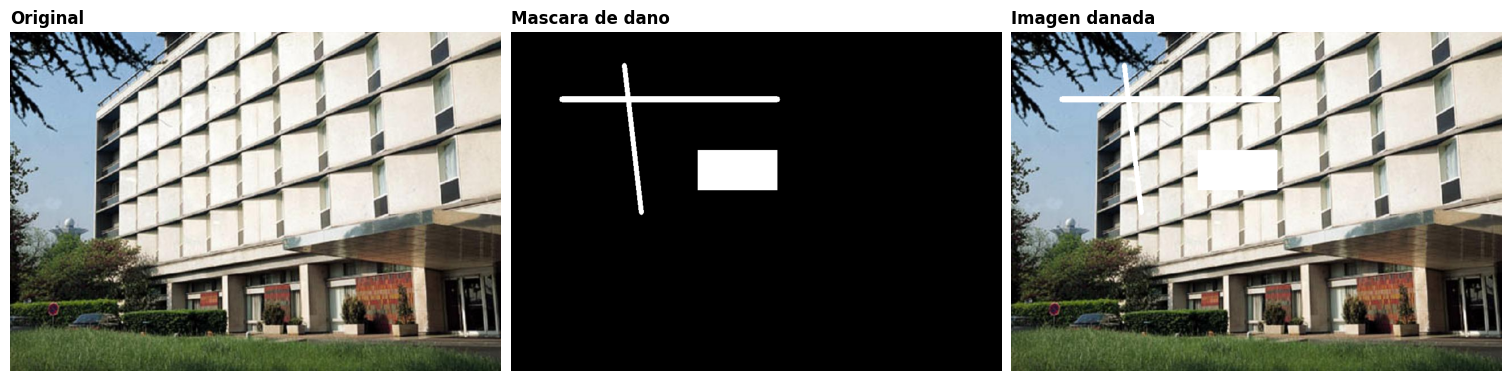

In [4]:
# Se comparan la imagen original, la mascara y el resultado danado
# para entender que informacion perdio el algoritmo antes de restaurar.
fig, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
ejes[0].imshow(imagen_rgb)
ejes[0].set_title("Original", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(mascara_dano, cmap="gray")
ejes[1].set_title("Mascara de dano", fontweight="bold", loc="left")
ejes[1].axis("off")
ejes[2].imshow(imagen_danada_rgb)
ejes[2].set_title("Imagen danada", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()


## 2. Aplicar dos métodos de inpainting

OpenCV ofrece dos variantes conocidas. Las vamos a usar con la misma máscara para ver cómo cambia la reconstrucción.


In [5]:
# Telea propaga informacion cercana de forma rapida y suele verse
# convincente en danos pequenos o lineales.
imagen_telea_bgr = cv2.inpaint(imagen_danada_bgr, mascara_dano, 3, cv2.INPAINT_TELEA)

# Navier-Stokes intenta continuar estructuras a partir del entorno.
imagen_ns_bgr = cv2.inpaint(imagen_danada_bgr, mascara_dano, 3, cv2.INPAINT_NS)

# Convertimos ambos resultados a RGB para compararlos.
imagen_telea_rgb = cv2.cvtColor(imagen_telea_bgr, cv2.COLOR_BGR2RGB)
imagen_ns_rgb = cv2.cvtColor(imagen_ns_bgr, cv2.COLOR_BGR2RGB)


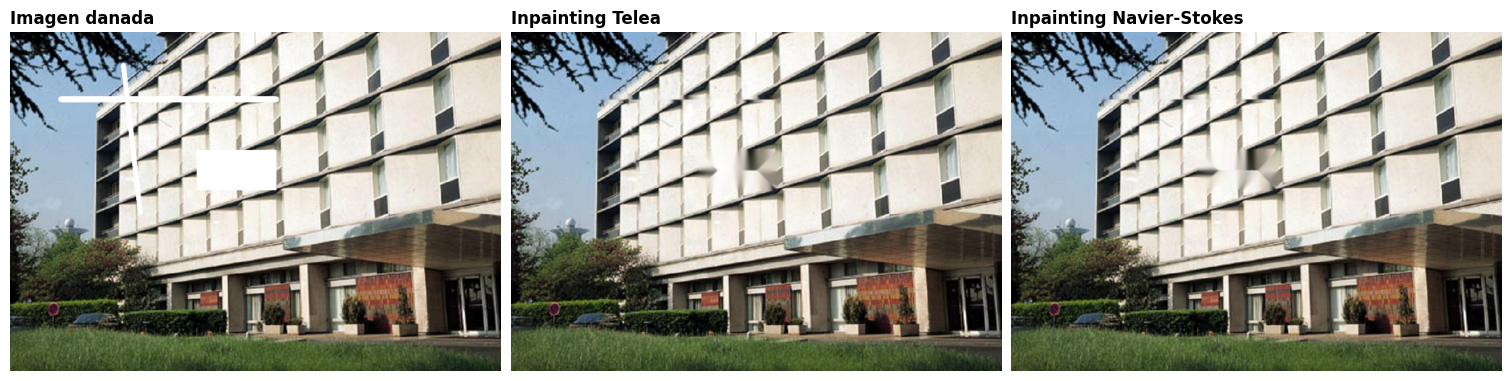

In [6]:
# Esta comparacion global permite ver cual metodo deja menos marcas
# artificiales y cual reconstruye mejor las zonas grandes danadas.
fig, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
ejes[0].imshow(imagen_danada_rgb)
ejes[0].set_title("Imagen danada", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(imagen_telea_rgb)
ejes[1].set_title("Inpainting Telea", fontweight="bold", loc="left")
ejes[1].axis("off")
ejes[2].imshow(imagen_ns_rgb)
ejes[2].set_title("Inpainting Navier-Stokes", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()


## 3. Mirar una región local

En restauración, la comparación global no siempre alcanza. Una zona recortada ayuda a ver si las líneas continúan de forma plausible o si la reconstrucción deja marcas artificiales.


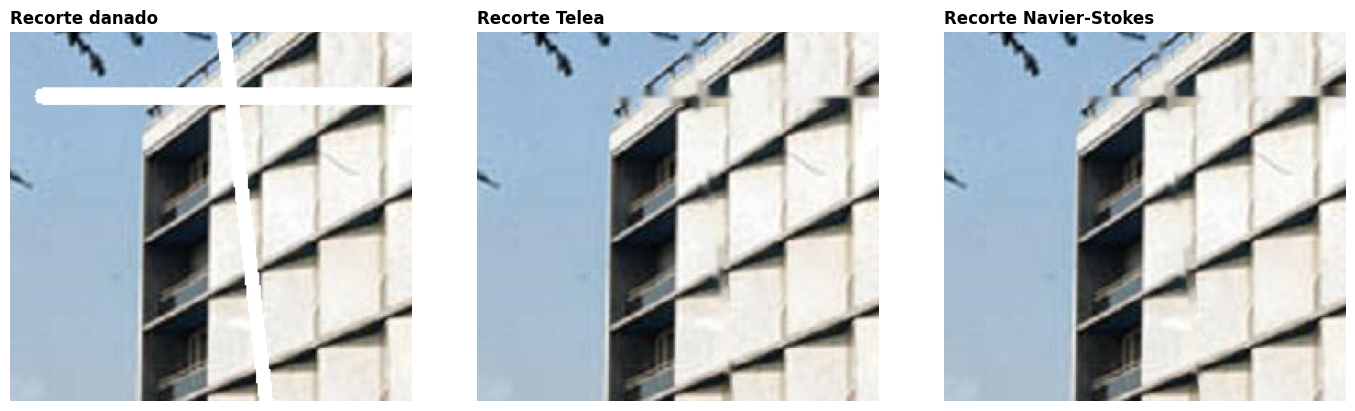

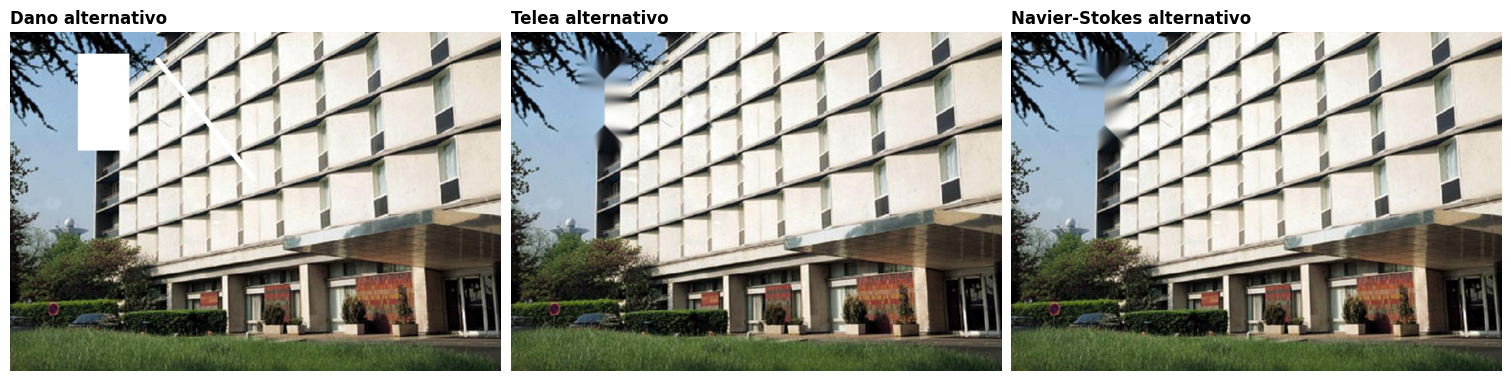

In [7]:
# Se define un recorte para mirar continuidad de lineas y texturas locales.
fila_inicial, fila_final = 80, 310
columna_inicial, columna_final = 70, 320

recorte_danado = imagen_danada_rgb[fila_inicial:fila_final, columna_inicial:columna_final]
recorte_telea = imagen_telea_rgb[fila_inicial:fila_final, columna_inicial:columna_final]
recorte_ns = imagen_ns_rgb[fila_inicial:fila_final, columna_inicial:columna_final]

fig, ejes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
ejes[0].imshow(recorte_danado)
ejes[0].set_title("Recorte danado", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(recorte_telea)
ejes[1].set_title("Recorte Telea", fontweight="bold", loc="left")
ejes[1].axis("off")
ejes[2].imshow(recorte_ns)
ejes[2].set_title("Recorte Navier-Stokes", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()

# Actividad extendida: danamos otra zona y repetimos el experimento.
mascara_dano_alternativa = np.zeros((alto, ancho), dtype=np.uint8)
cv2.rectangle(mascara_dano_alternativa, (120, 40), (210, 210), 255, -1)
cv2.line(mascara_dano_alternativa, (260, 50), (430, 260), 255, 7)

imagen_danada_alt_bgr = imagen_bgr.copy()
imagen_danada_alt_bgr[mascara_dano_alternativa == 255] = (255, 255, 255)
imagen_danada_alt_rgb = cv2.cvtColor(imagen_danada_alt_bgr, cv2.COLOR_BGR2RGB)
imagen_telea_alt_rgb = cv2.cvtColor(cv2.inpaint(imagen_danada_alt_bgr, mascara_dano_alternativa, 3, cv2.INPAINT_TELEA), cv2.COLOR_BGR2RGB)
imagen_ns_alt_rgb = cv2.cvtColor(cv2.inpaint(imagen_danada_alt_bgr, mascara_dano_alternativa, 3, cv2.INPAINT_NS), cv2.COLOR_BGR2RGB)

fig, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
ejes[0].imshow(imagen_danada_alt_rgb)
ejes[0].set_title("Dano alternativo", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(imagen_telea_alt_rgb)
ejes[1].set_title("Telea alternativo", fontweight="bold", loc="left")
ejes[1].axis("off")
ejes[2].imshow(imagen_ns_alt_rgb)
ejes[2].set_title("Navier-Stokes alternativo", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()


Acá la pregunta importante no es si el algoritmo “adivinó” exactamente el original, sino si logró una reconstrucción verosímil para la zona dañada. En restauración automática, esa diferencia es clave.


## Actividad breve

Modifica la mascara de dano para que afecte otra zona de la imagen y repeti el experimento. 


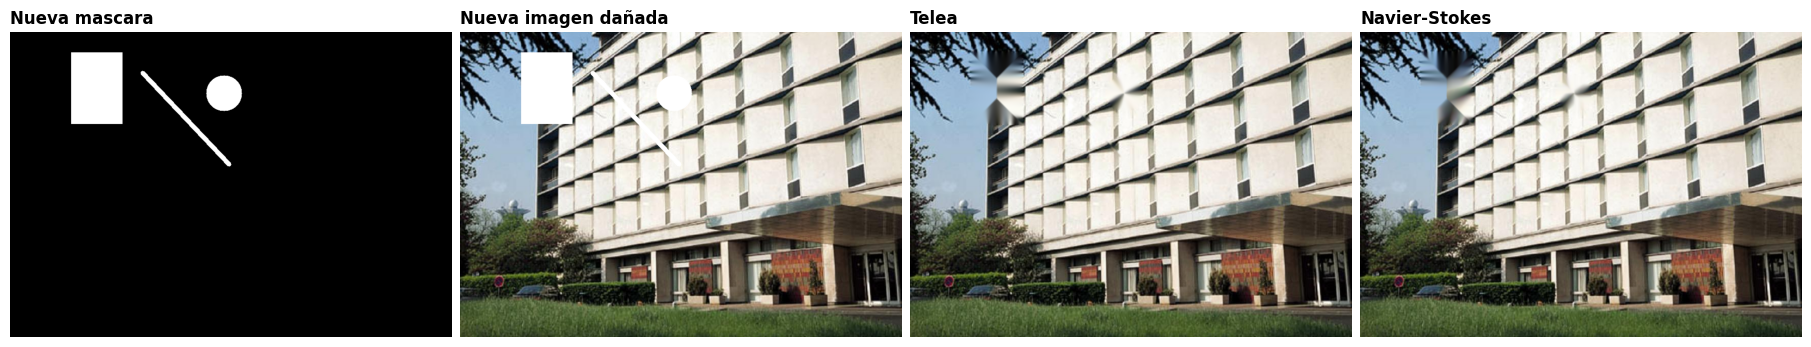

In [8]:
# Nueva mascara de daño en otra zona de la imagen
mascara_dano_nueva = np.zeros((alto, ancho), dtype=np.uint8)

# Se agregan daños en otra región para comparar la reconstrucción
cv2.rectangle(mascara_dano_nueva, (120, 40), (220, 180), 255, -1)
cv2.line(mascara_dano_nueva, (260, 80), (430, 260), 255, 8)
cv2.circle(mascara_dano_nueva, (420, 120), 35, 255, -1)

# Se genera una nueva imagen dañada a partir de la original
imagen_danada_nueva_bgr = imagen_bgr.copy()
imagen_danada_nueva_bgr[mascara_dano_nueva == 255] = (255, 255, 255)
imagen_danada_nueva_rgb = cv2.cvtColor(imagen_danada_nueva_bgr, cv2.COLOR_BGR2RGB)

# Se aplican nuevamente los dos métodos de inpainting
imagen_telea_nueva_bgr = cv2.inpaint(
    imagen_danada_nueva_bgr,
    mascara_dano_nueva,
    3,
    cv2.INPAINT_TELEA
)

imagen_ns_nueva_bgr = cv2.inpaint(
    imagen_danada_nueva_bgr,
    mascara_dano_nueva,
    3,
    cv2.INPAINT_NS
)

# Se convierten a RGB para visualizar con Matplotlib
imagen_telea_nueva_rgb = cv2.cvtColor(imagen_telea_nueva_bgr, cv2.COLOR_BGR2RGB)
imagen_ns_nueva_rgb = cv2.cvtColor(imagen_ns_nueva_bgr, cv2.COLOR_BGR2RGB)

# Comparación visual
fig, ejes = plt.subplots(1, 4, figsize=(18, 5), constrained_layout=True)

ejes[0].imshow(mascara_dano_nueva, cmap="gray")
ejes[0].set_title("Nueva mascara", fontweight="bold", loc="left")
ejes[0].axis("off")

ejes[1].imshow(imagen_danada_nueva_rgb)
ejes[1].set_title("Nueva imagen dañada", fontweight="bold", loc="left")
ejes[1].axis("off")

ejes[2].imshow(imagen_telea_nueva_rgb)
ejes[2].set_title("Telea", fontweight="bold", loc="left")
ejes[2].axis("off")

ejes[3].imshow(imagen_ns_nueva_rgb)
ejes[3].set_title("Navier-Stokes", fontweight="bold", loc="left")
ejes[3].axis("off")

plt.show()


1. que estructura era mas dificil de reconstruir;
La estructura mas dificil de reconstruir fue la zona donde el dano cruzo bordes rectos y cambios de textura al mismo tiempo.
2. cual de los dos metodos te resulto mas convincente;
En esta prueba, Telea resulto mas convincente en danos finos y lineales, mientras que Navier-Stokes mantuvo mejor algunas continuidades suaves.
3. por que restaurar no es lo mismo que recuperar informacion exacta.
Restaurar no es recuperar informacion exacta porque el algoritmo no conoce el contenido perdido: solo infiere una version plausible a partir del entorno.


## Cierre

Los algoritmos de inpainting pueden producir resultados visualmente razonables, pero no recuperan mágicamente la información perdida. Lo que hacen es proponer una reconstrucción plausible a partir del contexto cercano. Por eso conviene evaluarlos siempre con criterio visual y técnico.
